<a href="https://colab.research.google.com/github/muhsina419/Machine_learning_-_Parallel_computing_s6/blob/main/Q8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving OIP.jpg to OIP (2).jpg
✅ Image loaded successfully


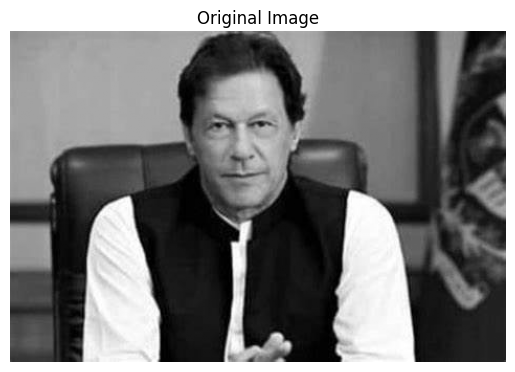


⏱ Sequential Time: 0.031603 seconds
⚡ Parallel Time: 0.009043 seconds

🚀 Speedup: 3.4948
⚙️ Efficiency: 0.8737

💾 Images saved: blur.jpg, sharpen.jpg, edge.jpg

🖼 Blur Image:


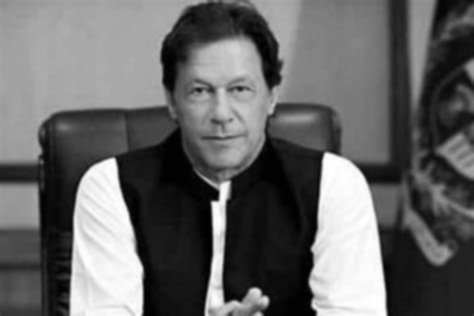


🖼 Sharpen Image:


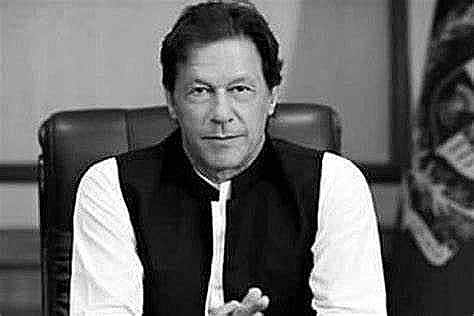


🖼 Edge Image:


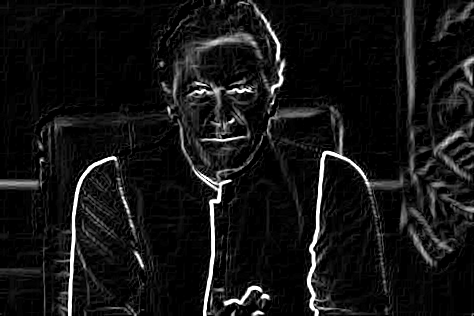

In [2]:
# ============================================
# A. IMPORT LIBRARIES
# ============================================
import cv2
import numpy as np
import time
import matplotlib.pyplot as plt
from google.colab import files
from google.colab.patches import cv2_imshow
from multiprocessing.dummy import Pool  # Thread-based parallelism

# ============================================
# B. LOAD IMAGE
# ============================================
uploaded = files.upload()

# Get uploaded filename automatically
file_name = list(uploaded.keys())[0]

# Read image in grayscale
img = cv2.imread(file_name, 0)

# Validate image
if img is None:
    raise ValueError("❌ Image not found or failed to load")
else:
    print("✅ Image loaded successfully")

# Display image
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

# ============================================
# C. DEFINE KERNELS
# ============================================
blur_kernel = np.ones((3, 3)) / 9

sharpen_kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

sobel_y = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
])

# ============================================
# D. FILTER FUNCTION
# ============================================
def apply_filter(args):
    image, kernel = args
    return cv2.filter2D(image, -1, kernel)

# ============================================
# E. SEQUENTIAL PROCESSING
# ============================================
seq_start = time.time()

blur_seq = cv2.filter2D(img, -1, blur_kernel)
sharp_seq = cv2.filter2D(img, -1, sharpen_kernel)

gx_seq = cv2.filter2D(img, -1, sobel_x)
gy_seq = cv2.filter2D(img, -1, sobel_y)

edge_seq = cv2.magnitude(gx_seq.astype(float), gy_seq.astype(float))

seq_time = time.time() - seq_start

print(f"\n⏱ Sequential Time: {seq_time:.6f} seconds")

# ============================================
# F. PARALLEL PROCESSING
# ============================================
par_start = time.time()

with Pool(4) as p:
    blur_par, sharp_par, gx_par, gy_par = p.map(apply_filter, [
        (img, blur_kernel),
        (img, sharpen_kernel),
        (img, sobel_x),
        (img, sobel_y)
    ])

edge_par = cv2.magnitude(gx_par.astype(float), gy_par.astype(float))

par_time = time.time() - par_start

print(f"⚡ Parallel Time: {par_time:.6f} seconds")

# ============================================
# G. PERFORMANCE METRICS
# ============================================
speedup = seq_time / par_time if par_time > 0 else 0
efficiency = speedup / 4

print(f"\n🚀 Speedup: {speedup:.4f}")
print(f"⚙️ Efficiency: {efficiency:.4f}")

# ============================================
# H. SAVE OUTPUT IMAGES
# ============================================
cv2.imwrite("blur.jpg", blur_par)
cv2.imwrite("sharpen.jpg", sharp_par)
cv2.imwrite("edge.jpg", edge_par)

print("\n💾 Images saved: blur.jpg, sharpen.jpg, edge.jpg")

# ============================================
# I. DISPLAY OUTPUT
# ============================================
print("\n🖼 Blur Image:")
cv2_imshow(blur_par)

print("\n🖼 Sharpen Image:")
cv2_imshow(sharp_par)

print("\n🖼 Edge Image:")
cv2_imshow(edge_par)